In [1]:
import scqubits
import numpy as np
  
import sys
sys.path.append('../')
from utils_models import *


In [2]:
EJ = 3
EC = EJ/4
EL = EJ/20.5  
max_ol = 80
max_ql = 30
g = 0.20
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = 8.46111172,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]

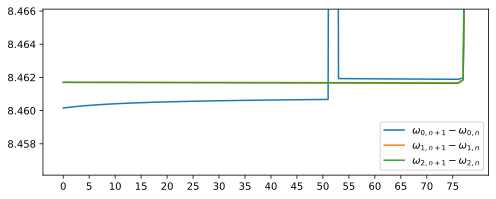

In [6]:
plt.figure(figsize = (8,3))
n_osc_lvls = max_ol-1
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::5])
plt.ylim(8.46111172-0.005, 8.46111172+0.005)
# plt.ylim(7.9,7.92)
# plt.xticklabels([str(i) for i in range(n_osc_lvls)])
plt.legend(loc='lower right')

In [7]:
def generate_excitation_array_1d(dims):
    arr = np.zeros(dims)
    for dim_index, dim_size in enumerate(dims):
        indices = [slice(None)] * len(dims)
        for level in range(dim_size):
            indices[dim_index] = level
            arr[tuple(indices)] += level
    flattened_arr = arr.flatten()
    return flattened_arr

def generate_single_mapping(H_with_interaction_no_drive) -> np.ndarray:
    """
    This function uses both the overlap (when dressed state is expressed in the product basis)
        and the total excitation number (each product state correspond to a total exictation number)
        to determine the mapping from dressed states to product states
    """

H_with_interaction_no_drive = system.hilbertspace.hamiltonian()


# 1)
evals, evecs = H_with_interaction_no_drive.eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)  # overlap_matrix[dressed_idx,product_idx] is the overlap. sum of overlap^2 is 1

# 2)
dims = H_with_interaction_no_drive.dims[0]
system_size = len(dims)
excitation_number_in_product_indices = generate_excitation_array_1d(dims)

def get_excitation_number_of_dressed_state(dressed_index):
    overlap_squared = overlap_matrix[dressed_index, :]**2
    return excitation_number_in_product_indices@overlap_squared

In [8]:
get_excitation_number_of_dressed_state = np.vectorize(get_excitation_number_of_dressed_state)

In [13]:
import itertools

product_state_names = list(itertools.product(*[range(dim) for dim in dims]))
product_index_map = {product: index for index, product in enumerate(product_state_names)}


total_dim = math.prod(dims)
dressed_indices_of_product_states = [None] * total_dim
product_to_dressed = {}
# for every energy eigenstate, from the lowerst to the highest, find the product state
# for dressed_index in range(len(evals)):
#     sorted_row = np.sort(np.abs(overlap_matrix[dressed_index, :]))[::-1]
#     n_th_largest_overlap = 0
#     found = False
#     show = False
#     while not found:
#         product_index = np.where(np.abs(overlap_matrix[dressed_index, :]) == sorted_row[n_th_largest_overlap])[0][0]
#         product = product_state_names[int(product_index)]
#         ql, ol = product
#         excitation_dressed = get_excitation_number_of_dressed_state(dressed_index)
#         excitation_bare = ql+ol
#         diff  = abs(excitation_bare - excitation_dressed)
#         if diff <= 1:
#             found = True
#         else:
#             show = True
#             print(f"dressed_index: {dressed_index}, excitation diff: {diff}, overlap^2 {sorted_row[n_th_largest_overlap]**2}")
#             n_th_largest_overlap += 1
#     if show:
#         print(f"Final dressed_index: {dressed_index}, excitation diff: {diff}, overlap^2 {sorted_row[n_th_largest_overlap]**2}")
#         print(" ")
#         show = False
#     product_to_dressed[product] = dressed_index

for product_index in range(len(evals)):
    sorted_overlaps_with_dressed_states = np.sort(np.abs(overlap_matrix[:, product_index]))[::-1]
    sorted_dressed_state_overlaps = np.argsort(np.abs(overlap_matrix[:, 0]))[::-1]
    sorted_total_dressed_exitations = get_excitation_number_of_dressed_state(sorted_overlaps_with_dressed_states)

    product = product_state_names[product_index]
    ql, ol = product
    excitation_bare = ql+ol


    # n_th_largest_overlap = 0
    # found = False
    # while not found:
    #     product_index = np.where(np.abs(overlap_matrix[dressed_index, :]) == sorted_row[n_th_largest_overlap])[0][0]
    #     product = product_state_names[product_index]
    #     ql, ol = product
    #     excitation_dressed = get_excitation_number_of_dressed_state(dressed_index)
    #     excitation_bare = ql+ol
    #     diff  = abs(excitation_bare - excitation_dressed)
    #     if diff <= 1:
    #         found = True
    #     else:
    #         print(f"dressed_index: {dressed_index}, excitation diff: {diff}, overlap^2 {sorted_row[n_th_largest_overlap]**2}")
    #         n_th_largest_overlap += 1

    # product_to_dressed[product] = dressed_index



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [10]:
def print_numbers(product):
    product_index = product_index_map[product]

    sorted_overlaps_with_dressed_states = np.sort(np.abs(overlap_matrix[:, product_index])**2)[::-1]
    sorted_dressed_state_overlaps = np.argsort(np.abs(overlap_matrix[:, product_index]))[::-1]
    sorted_total_dressed_exitations = get_excitation_number_of_dressed_state(sorted_dressed_state_overlaps)

    product = product_state_names[product_index]
    ql, ol = product
    excitation_bare = ql+ol

    sorted_excitation_diff = sorted_total_dressed_exitations - excitation_bare

    print(sorted_overlaps_with_dressed_states[:8])
    print('\n')
    print(sorted_excitation_diff[:8])
    print('\n')
    print(sorted_dressed_state_overlaps[:8])
    print('\n')

In [14]:
print_numbers((0,52))

[5.01377278e-01 4.83348387e-01 1.00810870e-02 1.79743325e-03
 1.70297720e-03 6.13164846e-04 3.05713594e-04 1.70734091e-04]


[3.01890719+0.j 3.12434047+0.j 2.28297899+0.j 4.29344321+0.j
 5.18782448+0.j 0.1080485 +0.j 9.78738695+0.j 2.11155784+0.j]


[1521 1520 1505 1565 1513 1501 1507 1561]




In [96]:
print_numbers((2,10))

[9.54124474e-01 2.04153745e-02 1.95905470e-02 2.12708423e-03
 1.59518373e-03 1.01152079e-03 4.52164267e-04 1.69987115e-04]


[ 0.67029739+0.j 23.48036331+0.j  7.84822433+0.j  2.32884122+0.j
  6.00569197+0.j  3.32722795+0.j  4.393365  +0.j  0.09007454+0.j]


[272 273 274 253 268 260 313 245]




In [116]:
print_numbers((2,9))

[9.74308150e-01 1.74909232e-02 2.90717453e-03 1.92429303e-03
 1.43895873e-03 9.17026710e-04 4.13181865e-04 1.53580294e-04]


[ 0.22834069+0.j  7.86428818+0.j 23.90711004+0.j  2.29552713+0.j
  6.00497077+0.j  3.35722971+0.j  4.36144502+0.j  0.08022482+0.j]


[242 244 243 223 238 230 283 215]




In [118]:
dressed_op = system.driven_operator
data  = np.abs(dressed_op.full())
for potential_state in [303, 302, 304 ,283 ,298 ,290 ,343, 275]:

    print(f"matrix element {data[272, potential_state]}, frequency {energies[potential_state] - energies[272]}")


matrix element 2.8214147358369988, frequency 8.658682736606139
matrix element 1.7182747229354807, frequency 8.65777101992417
matrix element 0.045962669003688714, frequency 8.756497002151349
matrix element 0.007844209454772676, frequency 3.349307379222523
matrix element 0.012231047833234698, frequency 7.968737743485477
matrix element 0.0077673555138639905, frequency 5.805753698288029
matrix element 7.71694003732604e-06, frequency 20.666705309123017
matrix element 0.0006676845711667307, frequency 0.720605658411543


In [117]:
data[272, 242]

3.1417042042645065

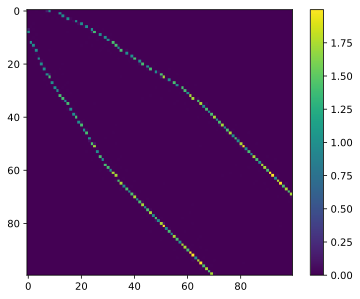

In [114]:
plt.imshow(np.abs(dressed_op.full())[:100,:100])
plt.colorbar() 

In [12]:
plt.plot(np.sort(sorted_total_dressed_exitations))
plt.ylim(0,25)
plt.xlim(0,300)

NameError: name 'sorted_total_dressed_exitations' is not defined